<a href="https://colab.research.google.com/github/anur8591/covid_19_project/blob/main/covide_19_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Covid_19_Clean_Complete -TA Ajinkya.csv to Covid_19_Clean_Complete -TA Ajinkya.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Covid_19_Clean_Complete -TA Ajinkya.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [5]:
# rename the column

df.rename(columns = {
    'Province/State':'State',
    'Country/Region':'Country'
}, inplace = True)

df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [6]:
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [7]:
df_total = df.groupby(['Country'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
df_total

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [8]:
df_confirmed = df.groupby(['Date'])[['Confirmed']].sum().reset_index()
df_confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


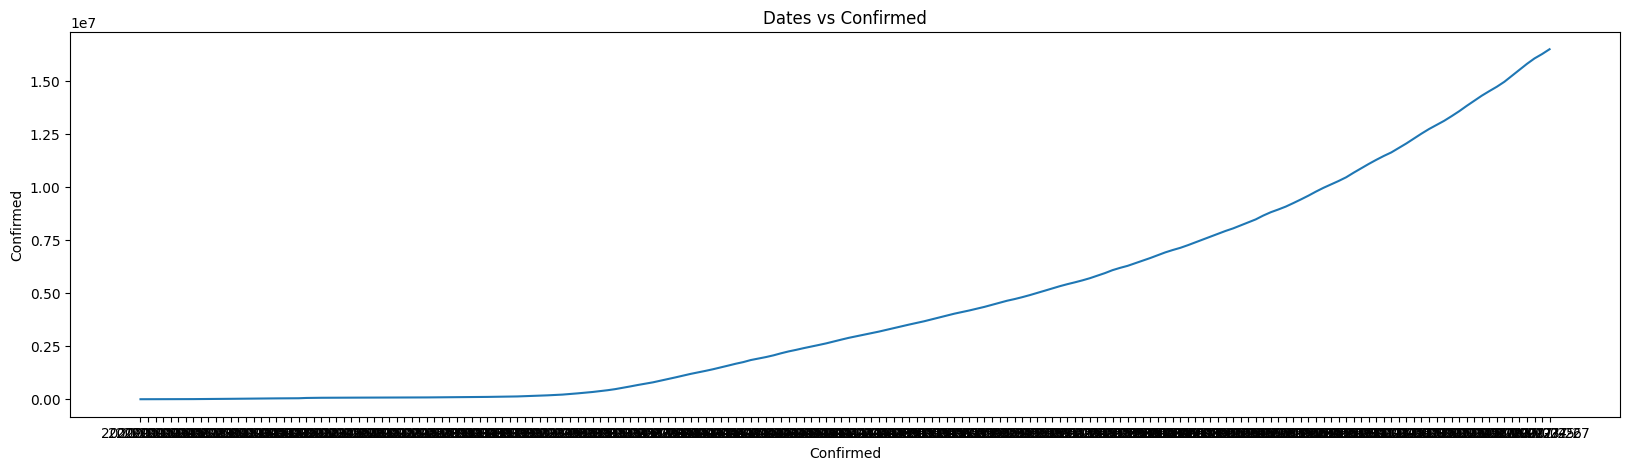

In [9]:
plt.figure(figsize = (20,5))
sns.lineplot(data = df_confirmed,x = 'Date',y = 'Confirmed')
plt.xlabel('Confirmed')
plt.title('Dates vs Confirmed')
plt.show()

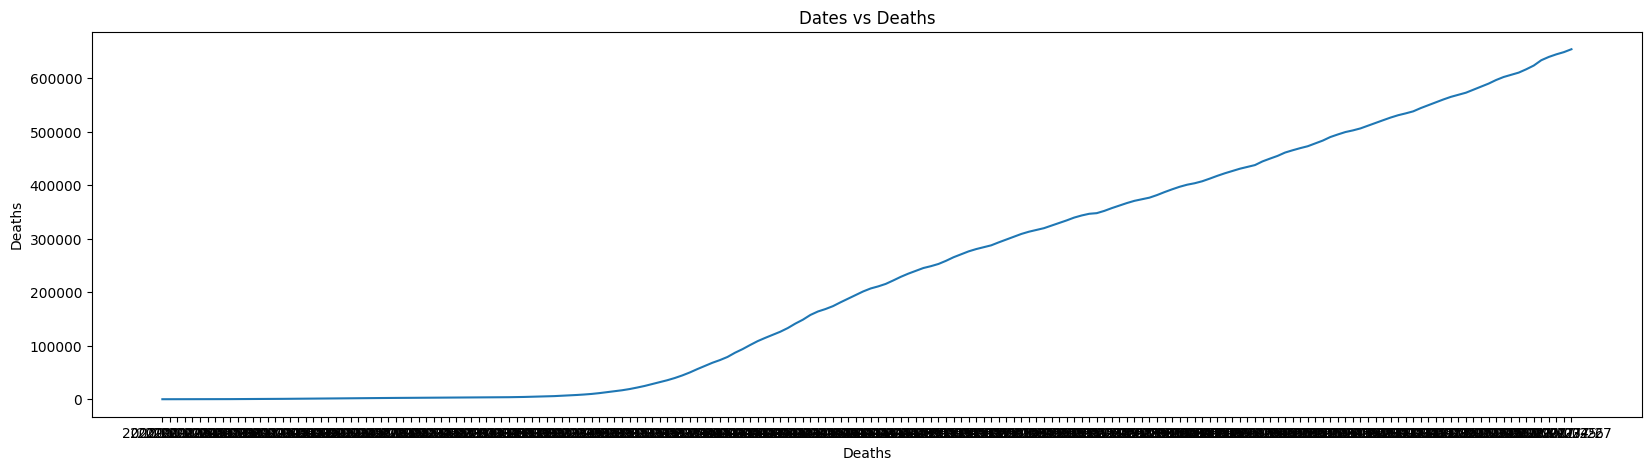

In [10]:
df_Deaths = df.groupby(['Date'])[['Deaths']].sum().reset_index()
df_Deaths

plt.figure(figsize = (20,5))
sns.lineplot(data = df_Deaths,x = 'Date',y = 'Deaths')
plt.xlabel('Deaths')
plt.title('Dates vs Deaths')
plt.show()

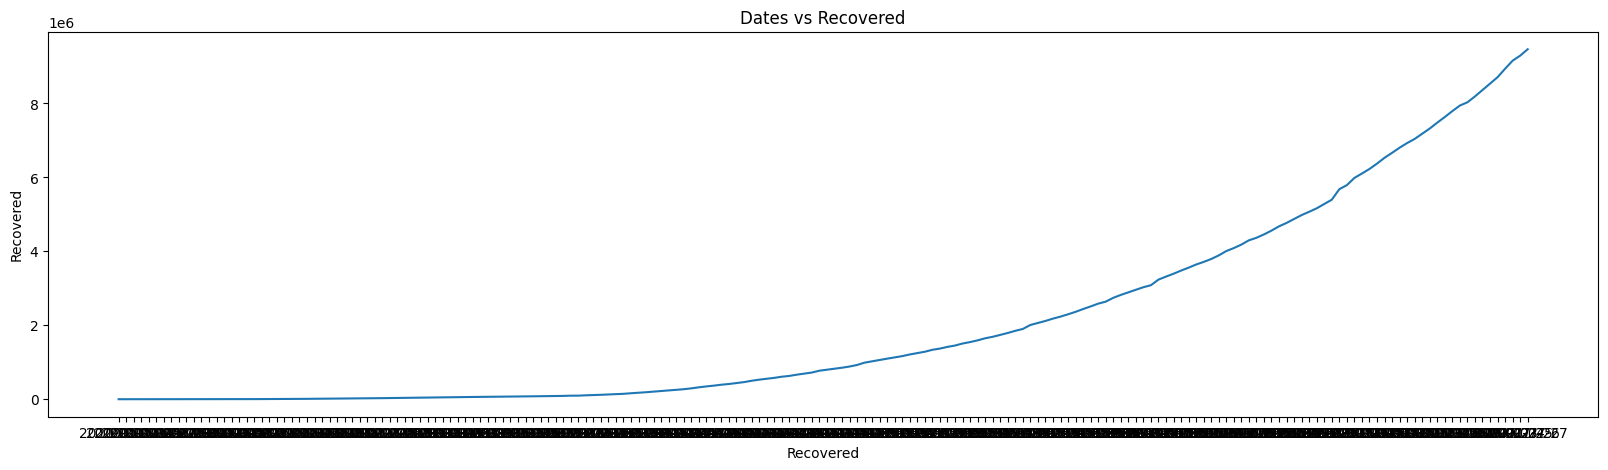

In [11]:
df_Recovered = df.groupby(['Date'])[['Recovered']].sum().reset_index()
df_Recovered

plt.figure(figsize = (20,5))
sns.lineplot(data = df_Recovered,x = 'Date',y = 'Recovered')
plt.xlabel('Recovered')
plt.title('Dates vs Recovered')
plt.show()

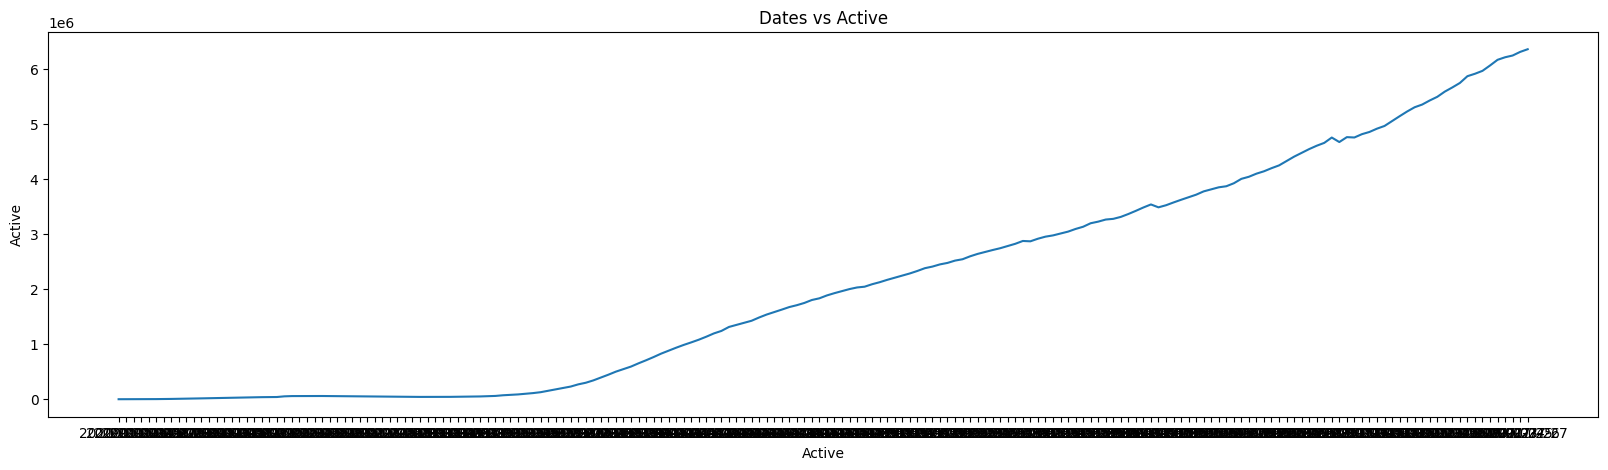

In [12]:
df_Active = df.groupby(['Date'])[['Active']].sum().reset_index()
df_Active

plt.figure(figsize = (20,5))
sns.lineplot(data = df_Active,x = 'Date',y = 'Active')
plt.xlabel('Active')
plt.title('Dates vs Active')
plt.show()

In [13]:
#prophet
"""
it is an industry level tool for time series forecasting.


prophet is a time series forcasting tool developed by facebook
that's designed to be easy to use and effictive for a wide range of time series data.
It's particularly useful for data that has strong seasonal effects (like daily or weekly patterns)
and includes important datas or events that can impact the forecast.
"""

""" *EXTRA Knowledge & explaination
ARIMA & SARIMA this all are very old to use in big or very large data or in big industry
level it algorithem is very old and outdated, so we comeup with the NEW one called "Prophet"
We just give the dataset to this model basicaly it not a model it's a tool "prophet"
"prophet" consist all the model, we just have to give the dataset to this too it will
automatically in the backend it will seclect optimal model, optimal PDQ values, it will compute
it and give me the forecasting value as well, we just want to give dataset it will perform everything
automatically
"""

!pip install prophet

In [14]:
# in prophet it's mandtroy to give the date column as "ds" and target as "y"
# because it's already predefine in the model(backend )

In [15]:
df_confirmed.columns = ['ds','y']
df_confirmed

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [16]:
from prophet import Prophet

In [20]:
model = Prophet()


In [21]:
model.fit(df_confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [23]:
# there is no training and testing data we have to give entire dataset to the model

In [25]:
future = model.make_future_dataframe(periods = 7)
forecasted_data = model.predict(future)

In [26]:
forecasted_data

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.283631e+05,8.208968e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.126768e+05,1.028627e+05,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.072097e+04,1.167129e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-8.558790e+04,1.152524e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-8.918737e+04,1.120347e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663454e+07,1.684193e+07,1.673892e+07,1.674823e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685170e+07,1.706130e+07,1.693721e+07,1.695642e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.706018e+07,1.727722e+07,1.713262e+07,1.716773e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725567e+07,1.746477e+07,1.732601e+07,1.738084e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [27]:
forecasted_data[['yhat_lower','yhat','yhat_upper']]

,yhat_lower,yhat,yhat_upper
0,-1.283631e+05,-2.067685e+04,8.208968e+04
1,-1.126768e+05,-8.050953e+03,1.028627e+05
2,-9.072097e+04,5.827449e+03,1.167129e+05
3,-8.558790e+04,1.217668e+04,1.152524e+05
4,-8.918737e+04,8.405020e+03,1.120347e+05
...,...,...,...
190,1.663454e+07,1.674392e+07,1.684193e+07
191,1.685170e+07,1.695911e+07,1.706130e+07
192,1.706018e+07,1.716677e+07,1.727722e+07
193,1.725567e+07,1.736430e+07,1.746477e+07


In [28]:
'''
ds:
This column the dates for which the predictions have been made.It stands for "data stamp."

yhat:
this is the predicted value(forecast)for the given data in the df column.It represents the model's best estimate for that point in

yhat_upper:
this column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.
it suggests that the actual value is likely to exceed this amount, giving you an idea  of the prediction's uncertainty.

yhat_lower:
This column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the



in short yhat is predicted value and yhat_upper and yhat_lower this are the bounderies where the predicted value lies between them

'''

'\nds:\nThis column the dates for which the predictions have been made.It stands for "data stamp."\n\nyhat:\nthis is the predicted value(forecast)for the given data in the df column.It represents the model\'s best estimate for that point in \n\nyhat_upper:\nthis column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.\nit suggests that the actual value is likely to exceed this amount, giving you an idea  of the prediction\'s uncertainty.\n\nyhat_lower:\nThis column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the \n\n\n\nin short yhat is predicted value and yhat_upper and yhat_lower this are the bounderies where the predicted value lies between them\n\n'

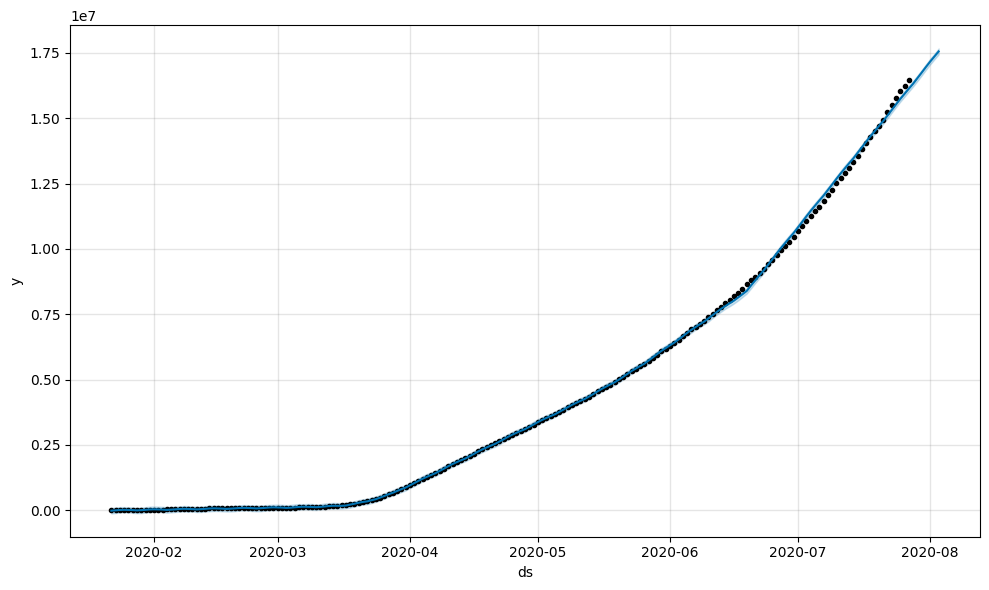

In [29]:
model.plot(forecasted_data)
plt.show()

In [30]:
import plotly
import plotly.express as ex

In [31]:
world = df.groupby(['Country'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
world

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [32]:
figure=ex.choropleth(world, locations = 'Country', locationmode = 'country names',color = 'Active',hover_name = 'Country',range_color = [1,100000],color_continuous_scale='reds',title = 'World map showing all the actives cases ')
figure.show()